# Imports

In [48]:
%cd ..
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from Modeling.utils_modeling import (chi2_TestIndependence, run_gridsearch)

pd.options.display.float_format = '{:.2f}'.format
%cd Modelling

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project


ModuleNotFoundError: No module named 'Modeling'

In [ ]:
%cd ..
data = pd.read_csv('Datasets/donors_train.csv')
data.head()


c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\Modelling


# Other/Extra

In [41]:
cat_cols = list(data.select_dtypes(include='str').columns) + ['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING']
cat_cols

['DONOR_GENDER',
 'HOME_OWNER',
 'RECENCY_STATUS_96NK',
 'SES',
 'URBANICITY',
 'INCOME_GROUP',
 'RECENT_STAR_STATUS',
 'WEALTH_RATING']

## Feature Selection?

In [42]:
data_no_nan = data.dropna()

In [43]:
chi2_TestIndependence(data_no_nan, 'TARGET_B', cat_cols)

,Column,Suggestion
0,DONOR_GENDER,Discard Feature
1,HOME_OWNER,Discard Feature
2,RECENCY_STATUS_96NK,Keep Feature
3,SES,Keep Feature
4,URBANICITY,Discard Feature
5,INCOME_GROUP,Discard Feature
6,RECENT_STAR_STATUS,Discard Feature
7,WEALTH_RATING,Discard Feature


In [44]:
chi2_TestIndependence(data, 'TARGET_B', cat_cols)

,Column,Suggestion
0,DONOR_GENDER,Discard Feature
1,HOME_OWNER,Keep Feature
2,RECENCY_STATUS_96NK,Keep Feature
3,SES,Keep Feature
4,URBANICITY,Keep Feature
5,INCOME_GROUP,Keep Feature
6,RECENT_STAR_STATUS,Keep Feature
7,WEALTH_RATING,Discard Feature


In [45]:
encoder = OrdinalEncoder()
encoded = encoder.fit_transform(data_no_nan[cat_cols])
encoded

array([[ 0.,  0.,  0., ...,  5.,  1.,  2.],
       [ 0.,  0.,  0., ...,  6.,  1.,  2.],
       [ 0.,  0.,  0., ...,  4.,  1.,  8.],
       ...,
       [ 1.,  1.,  5., ...,  2.,  2.,  7.],
       [ 1.,  0.,  0., ...,  6.,  1., 10.],
       [ 0.,  0.,  5., ...,  2.,  2.,  4.]], shape=(2345, 8))

In [46]:
anova = SelectKBest(f_classif, k='all')
X_anova = anova.fit_transform(encoded, data_no_nan['TARGET_B'])
selected_features = pd.Series(anova.get_support(), index = cat_cols)
selected_features

DONOR_GENDER           True
HOME_OWNER             True
RECENCY_STATUS_96NK    True
SES                    True
URBANICITY             True
INCOME_GROUP           True
RECENT_STAR_STATUS     True
WEALTH_RATING          True
dtype: bool

In [47]:
feature_scores = pd.Series(anova.pvalues_, index = cat_cols)
feature_scores

DONOR_GENDER          0.86
HOME_OWNER            0.23
RECENCY_STATUS_96NK   0.01
SES                   0.12
URBANICITY            0.42
INCOME_GROUP          0.05
RECENT_STAR_STATUS    0.68
WEALTH_RATING         0.26
dtype: float64

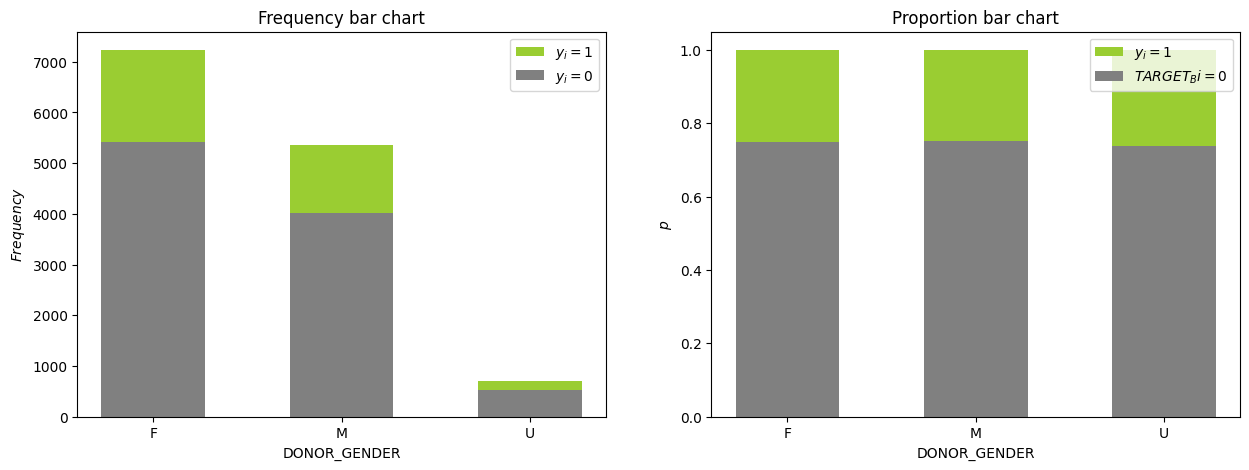

In [ ]:
bar_charts_categorical(data, ['DONOR_GENDER'], 'TARGET_B')

In [ ]:
corr = data[num_cols].corr('spearman')

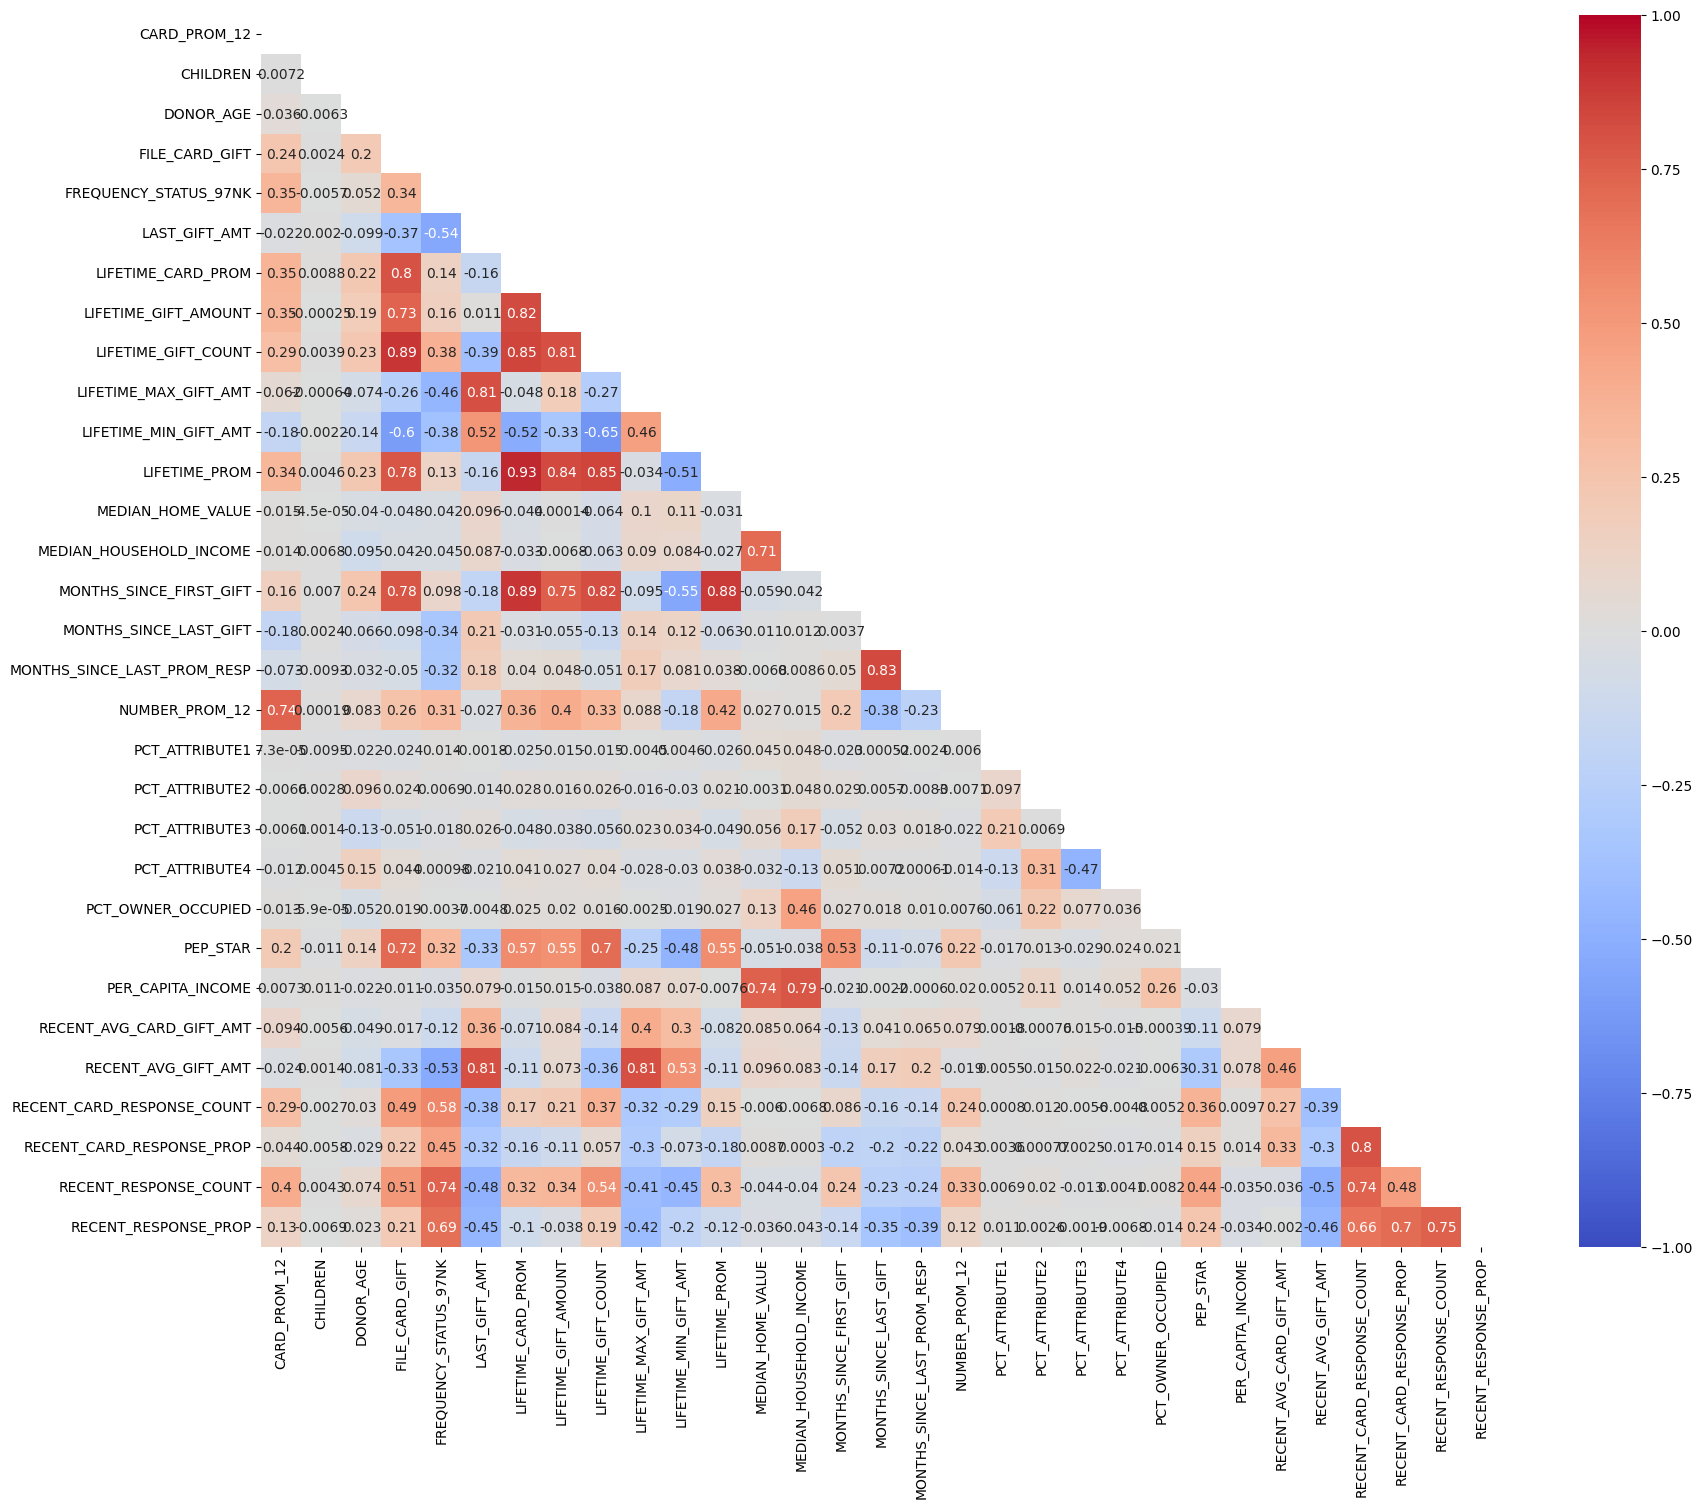

In [ ]:
cor_heatmap(data[num_cols].corr('spearman'))

## Modeling

In [ ]:
def preprocessing(train, val, imputer=None, scaler=None):
    # Outliers

    # Imputation
    if imputer:
        train_imputed = imputer.fit_transform(train)
        val_imputed = imputer.transform(val)
    # Feature Scaling
    if scaler:
        train_scaled = imputer.fit_transform(train)
        val_imputed = imputer.transform(val)
    # Feature Selection
    
    # Feature Encoding

### NaN

In [ ]:
pipe = Pipeline([       
    ('scaler', StandardScaler()),   
    ('imputer', KNNImputer()),          
    ('model', DecisionTreeClassifier(random_state=42)) 
])

In [ ]:
X = data.drop('TARGET_B', axis=1).select_dtypes('number')
y = data['TARGET_B']

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True)

In [ ]:
cv_result_test = cross_val_score(pipe, X, y, cv=skf, scoring='f1', n_jobs=-1)
cv_result_test

array([0.10707071, 0.04679666])

In [ ]:
cv_result = cross_validate(pipe, X, y, cv=skf, return_train_score=True, scoring='f1', n_jobs=-1)
cv_result

{'fit_time': array([2.49388909, 2.51474094]),
 'score_time': array([2.39642382, 2.43712044]),
 'test_score': array([0.09123898, 0.12042148]),
 'train_score': array([0.19120654, 0.19930244])}

In [ ]:
param_grid = [{
        'imputer': [KNNImputer(), None],
        'scaler':  [RobustScaler(), StandardScaler()],
        'model': [DecisionTreeClassifier(), RandomForestClassifier(), KNeighborsClassifier()]
}]

In [ ]:
def run_gridsearch(grid, cv, X, y):
    params = ParameterGrid(grid)
    results = []
    for param in tqdm(params, desc="Tuning Hyperparameters"):
        try:
            pipe.set_params(**param)
            cv_results = cross_validate(pipe, X, y, cv=skf, return_train_score=True, scoring='f1', n_jobs=-1)
            param['mean_val_f1'] = np.mean(cv_results['test_score'])
            param['std_val_f1'] = np.std(cv_results['test_score'])
            param['mean_train_f1'] = np.mean(cv_results['train_score'])
            param['std_train_f1'] = np.std(cv_results['train_score'])
            param['status'] = 'Success'
        except Exception as e:
            param['mean_val_f1'] = np.nan
            param['std_val_f1'] = np.nan
            param['mean_train_f1'] = np.nan
            param['std_train_f1'] = np.nan
            param['status'] = f'Failed: {str(e)[:50]}'
        results.append(param)
    return pd.DataFrame(results).sort_values('mean_val_f1')


In [ ]:
skf_test = StratifiedKFold(n_splits=10, shuffle=True, random_state=23)

In [ ]:
result_df = run_gridsearch(grid=param_grid, cv=skf_test, X=X, y=y)
result_df

Tuning Hyperparameters: 100%|██████████| 12/12 [00:52<00:00,  4.38s/it]


,imputer,model,scaler,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,status
8,None,RandomForestClassifier(),RobustScaler(),0.06,0.01,1.00,0.00,Success
2,KNNImputer(),RandomForestClassifier(),RobustScaler(),0.07,0.01,1.00,0.00,Success
9,None,RandomForestClassifier(),StandardScaler(),0.07,0.00,1.00,0.00,Success
3,KNNImputer(),RandomForestClassifier(),StandardScaler(),0.08,0.00,1.00,0.00,Success
5,KNNImputer(),KNeighborsClassifier(),StandardScaler(),0.18,0.01,0.39,0.01,Success
4,KNNImputer(),KNeighborsClassifier(),RobustScaler(),0.19,0.01,0.39,0.00,Success
0,KNNImputer(),DecisionTreeClassifier(),RobustScaler(),0.27,0.00,1.00,0.00,Success
7,None,DecisionTreeClassifier(),StandardScaler(),0.28,0.01,1.00,0.00,Success
6,None,DecisionTreeClassifier(),RobustScaler(),0.28,0.01,1.00,0.00,Success
1,KNNImputer(),DecisionTreeClassifier(),StandardScaler(),0.30,0.00,1.00,0.00,Success


In [ ]:
for status in result_df.status:
    print(status)

Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Failed: 
All the 2 fits failed.
It is very likely that you
Failed: 
All the 2 fits failed.
It is very likely that you




--- 5. RUN GRID SEARCH ---
 n_jobs=-1 uses all CPU cores. scoring='f1' targets your metric.
grid = GridSearchCV(pipe, param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=2)
grid.fit(X, y)

 --- 6. RESULTS ---
print(f"\nBest Cross-Validation F1 Score: {grid.best_score_:.4f}")
print("-" * 30)
print("Best Hyperparameters Found:")
for param, value in grid.best_params_.items():
    print(f"{param}: {value}")

pd.DataFrame(grid.cv_results_)

pipe.score(X, y)

def avg_scores(method,X,y, model):
    #lists to append the scores
    f1_train = []
    f1_test = []
    #scaler previously selected
    scaler = MinMaxScaler(feature_range = (-1,1))
    #KNN imputer with best number of neiberhoods
    imputer = KNNImputer(n_neighbors=optimal_n_neighbors, weights=optimal_weights)
    #do the interaction for every k fold or repeted k fold
    for train_index, test_index in method.split(X,y):
        #split
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        #scale
        X_train_scl = scaler.fit_transform(X_train)
        X_test_scl = scaler.transform(X_test)
        #impute
        X_train_scl_imp = imputer.fit_transform(X_train_scl)
        X_test_scl_imp = imputer.transform(X_test_scl)
        #fit and predict
        modelfit = model.fit(X_train_scl_imp, y_train)
        pred_train = modelfit.predict(X_train_scl_imp)
        pred_test = modelfit.predict(X_test_scl_imp)
        #calculate f1 and append
        f1_train.append(f1_score(y_train,pred_train))
        f1_test.append(f1_score(y_test,pred_test))
    #return the mean of f1
    print('Mean Train F1 Score:', np.mean(f1_train))
    print('Mean Validation F1 Score:', np.mean(f1_test))

### No NaN

In [ ]:
X_no_nan = data_no_nan.drop('TARGET_B', axis=1).select_dtypes('number')
y_no_nan = data_no_nan['TARGET_B']

In [ ]:
run_gridsearch(grid=param_grid, cv=skf_test, X=X_no_nan, y=y_no_nan)

Tuning Hyperparameters:   0%|          | 0/12 [00:00<?, ?it/s]

{'imputer': KNNImputer(), 'imputer__n_neighbors': 3, 'model': DecisionTreeClassifier(), 'scaler': RobustScaler()}
{'imputer': KNNImputer(n_neighbors=3), 'imputer__n_neighbors': 3, 'model': DecisionTreeClassifier(), 'scaler': StandardScaler()}
{'imputer': KNNImputer(n_neighbors=3), 'imputer__n_neighbors': 3, 'model': RandomForestClassifier(), 'scaler': RobustScaler()}


Tuning Hyperparameters:  25%|██▌       | 3/12 [00:00<00:01,  7.17it/s]

{'imputer': KNNImputer(n_neighbors=3), 'imputer__n_neighbors': 3, 'model': RandomForestClassifier(), 'scaler': StandardScaler()}


Tuning Hyperparameters:  33%|███▎      | 4/12 [00:00<00:01,  5.07it/s]

{'imputer': KNNImputer(n_neighbors=3), 'imputer__n_neighbors': 5, 'model': DecisionTreeClassifier(), 'scaler': RobustScaler()}
{'imputer': KNNImputer(), 'imputer__n_neighbors': 5, 'model': DecisionTreeClassifier(), 'scaler': StandardScaler()}
{'imputer': KNNImputer(), 'imputer__n_neighbors': 5, 'model': RandomForestClassifier(), 'scaler': RobustScaler()}


Tuning Hyperparameters:  58%|█████▊    | 7/12 [00:01<00:00,  6.20it/s]

{'imputer': KNNImputer(), 'imputer__n_neighbors': 5, 'model': RandomForestClassifier(), 'scaler': StandardScaler()}


Tuning Hyperparameters:  67%|██████▋   | 8/12 [00:01<00:00,  5.13it/s]

{'imputer': None, 'model': DecisionTreeClassifier(), 'scaler': RobustScaler()}
{'imputer': None, 'model': DecisionTreeClassifier(), 'scaler': StandardScaler()}
{'imputer': None, 'model': RandomForestClassifier(), 'scaler': RobustScaler()}


Tuning Hyperparameters:  92%|█████████▏| 11/12 [00:01<00:00,  6.02it/s]

{'imputer': None, 'model': RandomForestClassifier(), 'scaler': StandardScaler()}


Tuning Hyperparameters: 100%|██████████| 12/12 [00:02<00:00,  5.53it/s]


,imputer,imputer__n_neighbors,model,scaler,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,status
3,KNNImputer(),3.00,RandomForestClassifier(),StandardScaler(),0.10,0.04,1.00,0.00,Success
6,KNNImputer(),5.00,RandomForestClassifier(),RobustScaler(),0.10,0.02,1.00,0.00,Success
10,None,NaN,RandomForestClassifier(),RobustScaler(),0.11,0.01,1.00,0.00,Success
11,None,NaN,RandomForestClassifier(),StandardScaler(),0.12,0.00,1.00,0.00,Success
7,KNNImputer(),5.00,RandomForestClassifier(),StandardScaler(),0.12,0.01,1.00,0.00,Success
2,KNNImputer(),3.00,RandomForestClassifier(),RobustScaler(),0.13,0.02,1.00,0.00,Success
9,None,NaN,DecisionTreeClassifier(),StandardScaler(),0.28,0.01,1.00,0.00,Success
1,KNNImputer(),3.00,DecisionTreeClassifier(),StandardScaler(),0.29,0.01,1.00,0.00,Success
8,None,NaN,DecisionTreeClassifier(),RobustScaler(),0.29,0.00,1.00,0.00,Success
5,KNNImputer(),5.00,DecisionTreeClassifier(),StandardScaler(),0.30,0.01,1.00,0.00,Success


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
model.score(X_train, y_train)

0.7643923240938166

In [ ]:
train_pred = model.predict(X_train)

In [ ]:
f1_score(y_train, train_pred)

0.4106666666666667

In [ ]:
confusion_matrix(y_train, train_pred)

array([[1280,   93],
       [ 349,  154]])

In [ ]:
model.score(X_val, y_val)

0.6886993603411514

In [ ]:
val_pred = model.predict(X_val)

In [ ]:
f1_score(y_val, val_pred)

0.23958333333333334

In [ ]:
c

In [ ]:
confusion_matrix(y_val, val_pred)

array([[300,  43],
       [103,  23]])

In [ ]:
k_list = np.arange(1, 20)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in k_list:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    train_pred = knn_model.predict(X_train)
    val_pred = knn_model.predict(X_val)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

Best number of neighbors: 1
Mean F1 score in train with 1 neighbors: 1.000000
Mean F1 score in validation with 1 neighbors: 0.310606


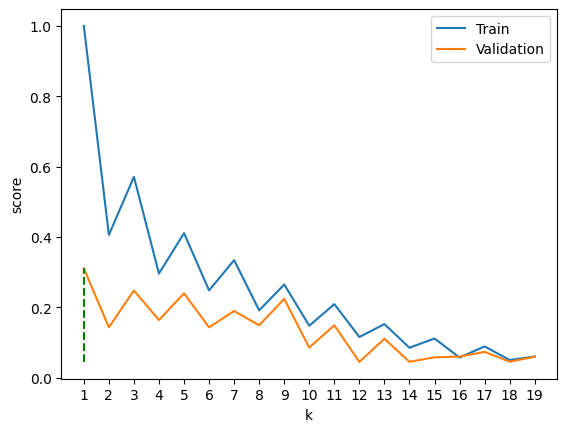

In [ ]:
plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()